In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Date

### A-vector best

In [91]:
df_predicts = pd.read_csv("datas/models/xgboosts_regression/predicts.csv")
df_trains = pd.read_csv("datas/models/xgboosts_regression/trains.csv")
df_metrics = pd.read_csv("datas/models/xgboosts_regression/metrics.csv")

In [48]:
temp = df_metrics[df_metrics['vector'] == 'A']
best_seed_A = temp['seed'][temp['pearson'] == temp['pearson'].max()].values[0]

In [49]:
best_seed_A

3862

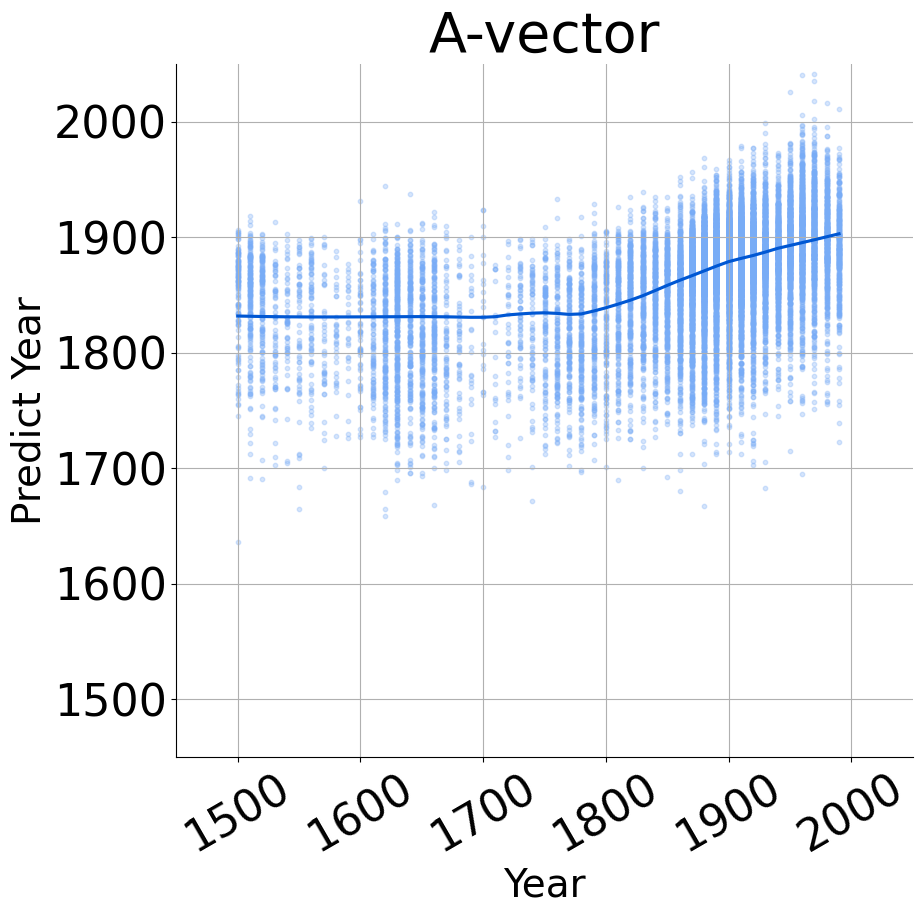

In [50]:
# 산점도 및 회귀선 그리기
fig, ax = plt.subplots(figsize=(9.5, 9))
# 위쪽과 오른쪽 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

y_test = df_predicts[[f'seed_{best_seed_A}_y_test_year']]
y_pre_avec = df_predicts[[f'seed_{best_seed_A}_A_pred_year']]

sns.regplot(x=y_test, y=y_pre_avec, scatter_kws={'s': 10,'alpha':0.3, 'color':'#78ACF6'}, line_kws={'color': '#0057D3'}, ax=ax, lowess=True)

plt.xlabel('Year',fontsize=28)  # x축 레이블 설정
plt.ylabel('Predict Year',fontsize=28)
plt.xlim(1450, 2050)
plt.ylim(1450, 2050)
plt.xticks([1500, 1600, 1700, 1800, 1900, 2000],fontsize=32, rotation=30)
plt.yticks([1500, 1600, 1700, 1800, 1900, 2000],fontsize=32)
plt.grid(True)
plt.title('A-vector', fontsize=40)
plt.savefig('graph/supple/si12_date_abest_avec.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

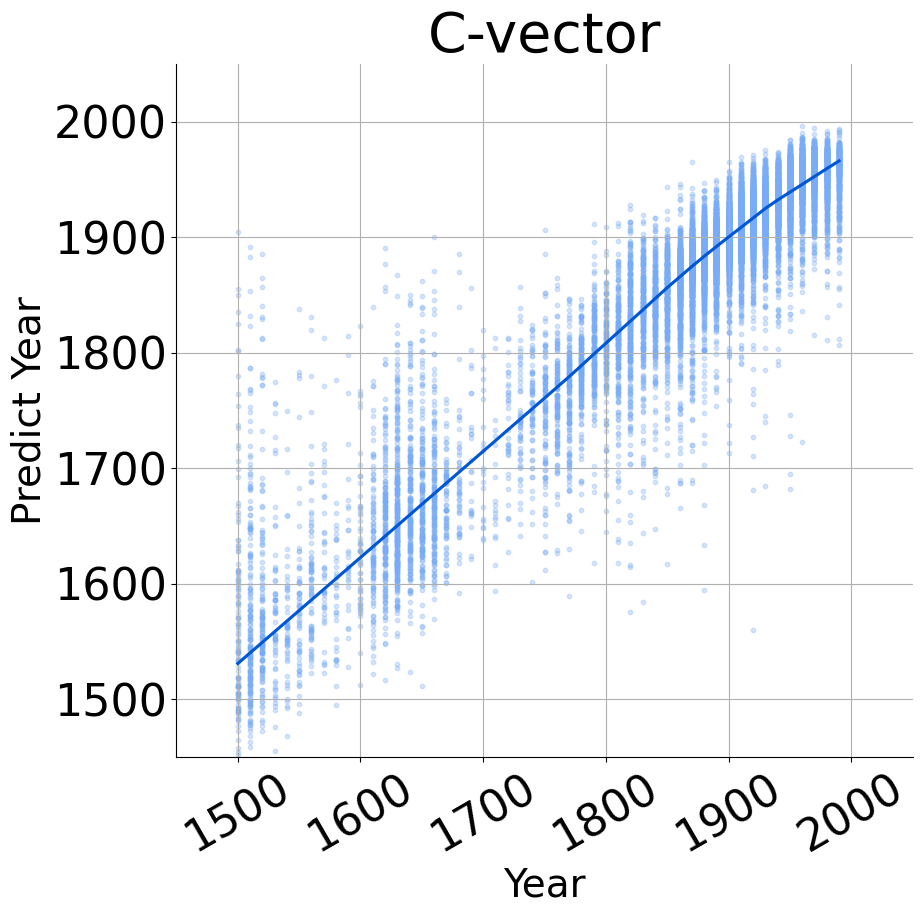

In [51]:
# 산점도 및 회귀선 그리기
fig, ax = plt.subplots(figsize=(9.5, 9))
# 위쪽과 오른쪽 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

y_test = df_predicts[[f'seed_{best_seed_A}_y_test_year']]
y_pre_cvec = df_predicts[[f'seed_{best_seed_A}_C_pred_year']]

sns.regplot(x=y_test, y=y_pre_cvec, scatter_kws={'s': 10,'alpha':0.3, 'color':'#78ACF6'}, line_kws={'color': '#0057D3'}, ax=ax, lowess=True)

plt.xlabel('Year',fontsize=28)  # x축 레이블 설정
plt.ylabel('Predict Year',fontsize=28)
plt.xlim(1450, 2050)
plt.ylim(1450, 2050)
plt.xticks([1500, 1600, 1700, 1800, 1900, 2000],fontsize=32, rotation=30)
plt.yticks([1500, 1600, 1700, 1800, 1900, 2000],fontsize=32)
plt.grid(True)
plt.title('C-vector', fontsize=40)
plt.savefig('graph/supple/si12_date_abest_cvec.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

In [52]:
df_metrics[df_metrics['seed']==best_seed_A]

,seed,vector,pearson,spearman,mae,rmse,r2
176,3862,C,0.934911,0.890276,2.285032,3.729067,0.873535
177,3862,A,0.466696,0.493860,6.111218,9.284488,0.216052


### Date classifier

In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
df = pd.read_csv("datas/models/xgboosts_regression/predicts.csv")

In [3]:
df

,seed_9124_index,seed_9124_y_test_year,seed_9124_C_pred_year,seed_9124_A_pred_year,seed_6225_index,seed_6225_y_test_year,seed_6225_C_pred_year,seed_6225_A_pred_year,seed_6360_index,seed_6360_y_test_year,...,seed_5078_C_pred_year,seed_5078_A_pred_year,seed_9069_index,seed_9069_y_test_year,seed_9069_C_pred_year,seed_9069_A_pred_year,seed_3776_index,seed_3776_y_test_year,seed_3776_C_pred_year,seed_3776_A_pred_year
0,72717,1930,1956.3947,1868.5226,6415,1910,1907.6685,1840.7474,27372,1900,...,1918.3517,1918.0027,21763,1870,1893.9380,1871.4541,7381,1920,1923.4333,1818.8360
1,42983,1640,1654.9171,1869.4578,53734,1930,1915.8135,1880.5837,1410,1810,...,1828.9407,1871.0562,3132,1910,1915.8726,1923.5522,46265,1500,1473.3380,1872.6174
2,1591,1930,1953.5739,1882.3391,45302,1550,1567.9795,1881.1116,18266,1900,...,1737.6641,1757.7072,50065,1960,1976.1376,1932.6263,32748,1890,1871.9775,1867.3307
3,41213,1650,1688.1244,1806.5710,43747,1620,1797.6161,1814.0100,29023,1870,...,1862.6880,1886.7141,19502,1930,1861.3445,1893.2917,13473,1880,1892.1447,1911.4033
4,18162,1920,1908.1378,1889.7876,72328,1920,1925.5426,1920.3022,69640,1930,...,1915.6011,1951.2397,66598,1920,1925.0592,1911.3790,25826,1890,1894.9501,1918.9612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21730,40382,1660,1627.0269,1766.7909,41079,1640,1674.9078,1749.0441,53950,1970,...,1977.6406,1976.2470,1428,1960,1906.9973,1904.7477,33753,1860,1833.1354,1813.8887
21731,10714,1900,1909.1083,1881.9149,50365,1980,1939.2438,1874.0033,49045,1990,...,1862.1243,1867.7509,16585,1880,1899.5549,1885.7756,363,1970,1947.2310,1882.3618
21732,8321,1880,1897.9945,1878.9822,24772,1890,1853.6025,1889.0751,13148,1900,...,1905.1011,1906.6490,26956,1870,1875.4860,1884.4371,43378,1610,1578.7562,1781.5662
21733,7347,1900,1887.0391,1914.5227,50281,1960,1969.4158,1894.1592,59702,1940,...,1910.2086,1910.7810,17735,1880,1875.2175,1878.3291,62511,1940,1933.5942,1887.9707


In [9]:
seed_numbers = []
for col in df.columns:
    if 'seed_' in col and '_index' in col:
        seed_num = col.replace('seed_', '').replace('_index', '')
        seed_numbers.append(seed_num)
print(len(seed_numbers))

100


In [19]:
long_format_list = []

for seed_num in seed_numbers:
    temp_df = pd.DataFrame({
        'Seed': seed_num,
        'Index': df[f'seed_{seed_num}_index'],
        'Year': df[f'seed_{seed_num}_y_test_year'],
        'CPred': df[f'seed_{seed_num}_C_pred_year'],
        'APred': df[f'seed_{seed_num}_A_pred_year']
    })
    long_format_list.append(temp_df)

# 모든 seed 데이터를 하나로 합치기
long_format = pd.concat(long_format_list, ignore_index=True)
long_format.to_csv("./predicted_longformat.csv", index=False)

In [24]:
def floor_to_decade(year):
    return (year // 10) * 10

# 10년 단위 차이 계산
long_format['CPred_decade'] = floor_to_decade(long_format['CPred'])
long_format['APred_decade'] = floor_to_decade(long_format['APred'])
long_format['Year_decade'] = floor_to_decade(long_format['Year'])

# 0 decade부터 10 decade까지
for tolerance in range(0, 11):
    long_format[f'C_{tolerance*10}'] = (
        np.abs(long_format['CPred_decade'] - long_format['Year_decade']) <= tolerance * 10
    )
    long_format[f'A_{tolerance*10}'] = (
        np.abs(long_format['APred_decade'] - long_format['Year_decade']) <= tolerance * 10
    )

# 결과 확인
#long_format

In [25]:
metrics_list = []

for seed in long_format['Seed'].unique():
    seed_data = long_format[long_format['Seed'] == seed]
    
    metrics = {'Seed': seed}
    
    # 각 tolerance별로 메트릭 계산
    for tolerance in range(0, 11):
        c_col = f'C_{tolerance*10}'
        a_col = f'A_{tolerance*10}'
        
        # CPred 메트릭
        metrics[f'{c_col}_accuracy'] = seed_data[c_col].mean()
        # True를 1로 봤을 때의 precision, recall, f1
        if seed_data[c_col].sum() > 0:  # 예측이 하나라도 있을 때
            metrics[f'{c_col}_precision'] = seed_data[c_col].sum() / len(seed_data)
            metrics[f'{c_col}_recall'] = seed_data[c_col].mean()
            metrics[f'{c_col}_f1'] = f1_score([True]*len(seed_data), seed_data[c_col])
        
        # APred 메트릭
        metrics[f'{a_col}_accuracy'] = seed_data[a_col].mean()
        if seed_data[a_col].sum() > 0:
            metrics[f'{a_col}_precision'] = seed_data[a_col].sum() / len(seed_data)
            metrics[f'{a_col}_recall'] = seed_data[a_col].mean()
            metrics[f'{a_col}_f1'] = f1_score([True]*len(seed_data), seed_data[a_col])
    
    metrics_list.append(metrics)

# 결과를 DataFrame으로
seed_metrics = pd.DataFrame(metrics_list)

In [34]:
seed_metrics.to_csv("raw_metrics_by_tolerance.csv", index=False)

In [28]:
summary_list = []

for tolerance in range(0, 11):
    tol_value = tolerance * 10
    
    # CPred 메트릭
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        col_name = f'C_{tol_value}_{metric}'
        if col_name in seed_metrics.columns:
            summary_list.append({
                'Tolerance': tol_value,
                'Pred_Type': 'C',
                'Metric': metric,
                'Mean': seed_metrics[col_name].mean(),
                'Std': seed_metrics[col_name].std(),
                'Min': seed_metrics[col_name].min(),
                'Q25': seed_metrics[col_name].quantile(0.25),
                'Median': seed_metrics[col_name].median(),
                'Q75': seed_metrics[col_name].quantile(0.75),
                'Max': seed_metrics[col_name].max()
            })
    
    # APred 메트릭
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        col_name = f'A_{tol_value}_{metric}'
        if col_name in seed_metrics.columns:
            summary_list.append({
                'Tolerance': tol_value,
                'Pred_Type': 'A',
                'Metric': metric,
                'Mean': seed_metrics[col_name].mean(),
                'Std': seed_metrics[col_name].std(),
                'Min': seed_metrics[col_name].min(),
                'Q25': seed_metrics[col_name].quantile(0.25),
                'Median': seed_metrics[col_name].median(),
                'Q75': seed_metrics[col_name].quantile(0.75),
                'Max': seed_metrics[col_name].max()
            })

# 결과를 DataFrame으로
tolerance_summary = pd.DataFrame(summary_list)

# 보기 좋게 정렬
tolerance_summary = tolerance_summary.sort_values(['Tolerance', 'Pred_Type', 'Metric'])



,Tolerance,Pred_Type,Metric,Mean,Std,Min,Q25,Median,Q75,Max
4,0,A,accuracy,0.070156,0.001863,0.065885,0.069002,0.069933,0.071314,0.076144
7,0,A,f1,0.131107,0.003251,0.123624,0.129095,0.130725,0.133133,0.141513
5,0,A,precision,0.070156,0.001863,0.065885,0.069002,0.069933,0.071314,0.076144
6,0,A,recall,0.070156,0.001863,0.065885,0.069002,0.069933,0.071314,0.076144
0,0,C,accuracy,0.188960,0.002403,0.182609,0.187302,0.189050,0.190706,0.196273
...,...,...,...,...,...,...,...,...,...,...
86,100,A,recall,0.835419,0.001731,0.831884,0.834081,0.835381,0.836531,0.840396
80,100,C,accuracy,0.975011,0.000893,0.973085,0.974362,0.975017,0.975707,0.977088
83,100,C,f1,0.987347,0.000458,0.986359,0.987014,0.987351,0.987704,0.988411
81,100,C,precision,0.975011,0.000893,0.973085,0.974362,0.975017,0.975707,0.977088


In [33]:
tolerance_summary.to_csv("metric_summary_by_tolerance.csv", index=False)

In [29]:
tolerance_summary[tolerance_summary["Tolerance"]==0]

,Tolerance,Pred_Type,Metric,Mean,Std,Min,Q25,Median,Q75,Max
4,0,A,accuracy,0.070156,0.001863,0.065885,0.069002,0.069933,0.071314,0.076144
7,0,A,f1,0.131107,0.003251,0.123624,0.129095,0.130725,0.133133,0.141513
5,0,A,precision,0.070156,0.001863,0.065885,0.069002,0.069933,0.071314,0.076144
6,0,A,recall,0.070156,0.001863,0.065885,0.069002,0.069933,0.071314,0.076144
0,0,C,accuracy,0.188960,0.002403,0.182609,0.187302,0.189050,0.190706,0.196273
3,0,C,f1,0.317851,0.003398,0.308824,0.315508,0.317985,0.320325,0.328141
1,0,C,precision,0.188960,0.002403,0.182609,0.187302,0.189050,0.190706,0.196273
2,0,C,recall,0.188960,0.002403,0.182609,0.187302,0.189050,0.190706,0.196273


In [30]:
tolerance_summary[tolerance_summary["Tolerance"]==10]

,Tolerance,Pred_Type,Metric,Mean,Std,Min,Q25,Median,Q75,Max
12,10,A,accuracy,0.205507,0.002894,0.199770,0.203520,0.205222,0.207051,0.215919
15,10,A,f1,0.340937,0.003978,0.333014,0.338207,0.340555,0.343069,0.355154
13,10,A,precision,0.205507,0.002894,0.199770,0.203520,0.205222,0.207051,0.215919
14,10,A,recall,0.205507,0.002894,0.199770,0.203520,0.205222,0.207051,0.215919
8,10,C,accuracy,0.502096,0.002912,0.494318,0.500610,0.502001,0.504359,0.509639
11,10,C,f1,0.668522,0.002583,0.661597,0.667208,0.668443,0.670530,0.675180
9,10,C,precision,0.502096,0.002912,0.494318,0.500610,0.502001,0.504359,0.509639
10,10,C,recall,0.502096,0.002912,0.494318,0.500610,0.502001,0.504359,0.509639


In [31]:
tolerance_summary[tolerance_summary["Tolerance"]==20]

,Tolerance,Pred_Type,Metric,Mean,Std,Min,Q25,Median,Q75,Max
20,20,A,accuracy,0.328819,0.003085,0.321923,0.326731,0.328893,0.331056,0.337612
23,20,A,f1,0.494896,0.003494,0.487053,0.492535,0.494988,0.497434,0.504798
21,20,A,precision,0.328819,0.003085,0.321923,0.326731,0.328893,0.331056,0.337612
22,20,A,recall,0.328819,0.003085,0.321923,0.326731,0.328893,0.331056,0.337612
16,20,C,accuracy,0.698223,0.002864,0.690867,0.696250,0.698229,0.700403,0.704164
19,20,C,f1,0.822295,0.001987,0.817175,0.820929,0.822302,0.823808,0.826404
17,20,C,precision,0.698223,0.002864,0.690867,0.696250,0.698229,0.700403,0.704164
18,20,C,recall,0.698223,0.002864,0.690867,0.696250,0.698229,0.700403,0.704164


In [32]:
tolerance_summary[tolerance_summary["Tolerance"]==30]

,Tolerance,Pred_Type,Metric,Mean,Std,Min,Q25,Median,Q75,Max
28,30,A,accuracy,0.437351,0.002725,0.428111,0.435565,0.437336,0.439349,0.443110
31,30,A,f1,0.608547,0.002640,0.599549,0.606820,0.608537,0.610483,0.614104
29,30,A,precision,0.437351,0.002725,0.428111,0.435565,0.437336,0.439349,0.443110
30,30,A,recall,0.437351,0.002725,0.428111,0.435565,0.437336,0.439349,0.443110
24,30,C,accuracy,0.809166,0.002169,0.804601,0.807626,0.808903,0.810755,0.815137
27,30,C,f1,0.894517,0.001325,0.891722,0.893576,0.894357,0.895488,0.898155
25,30,C,precision,0.809166,0.002169,0.804601,0.807626,0.808903,0.810755,0.815137
26,30,C,recall,0.809166,0.002169,0.804601,0.807626,0.808903,0.810755,0.815137


In [35]:
import seaborn as sns

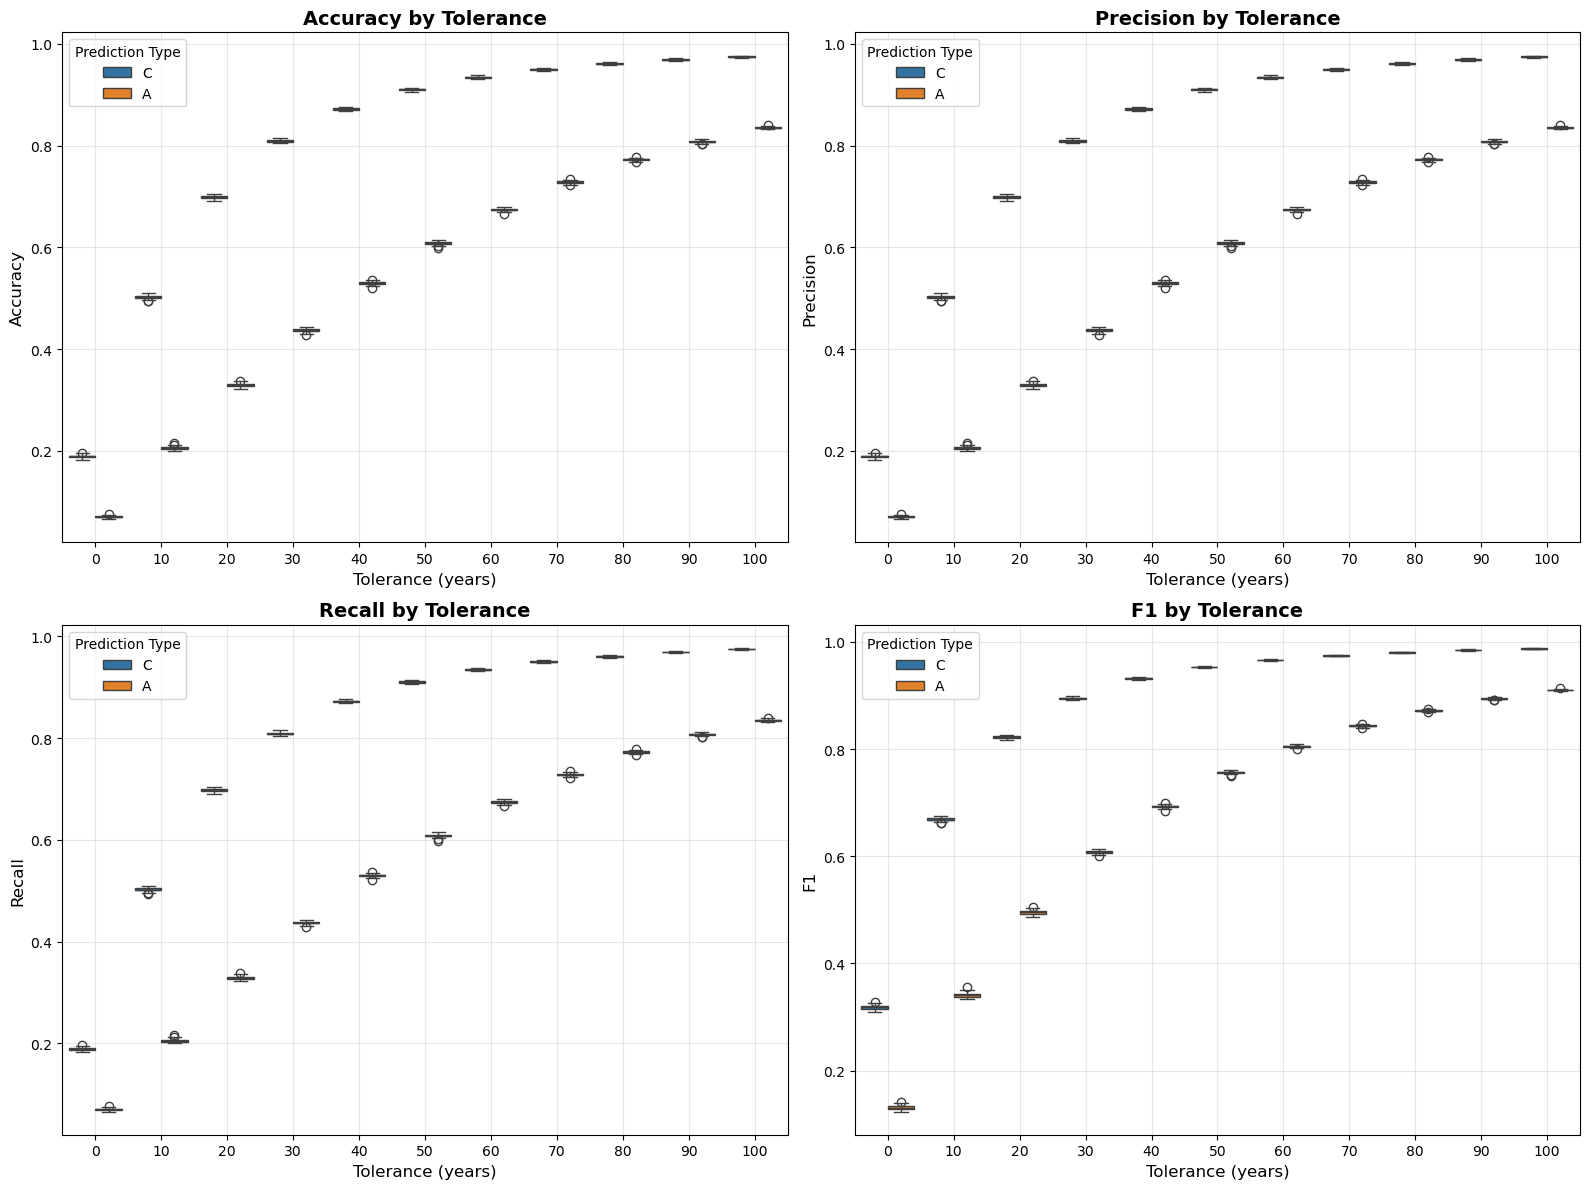

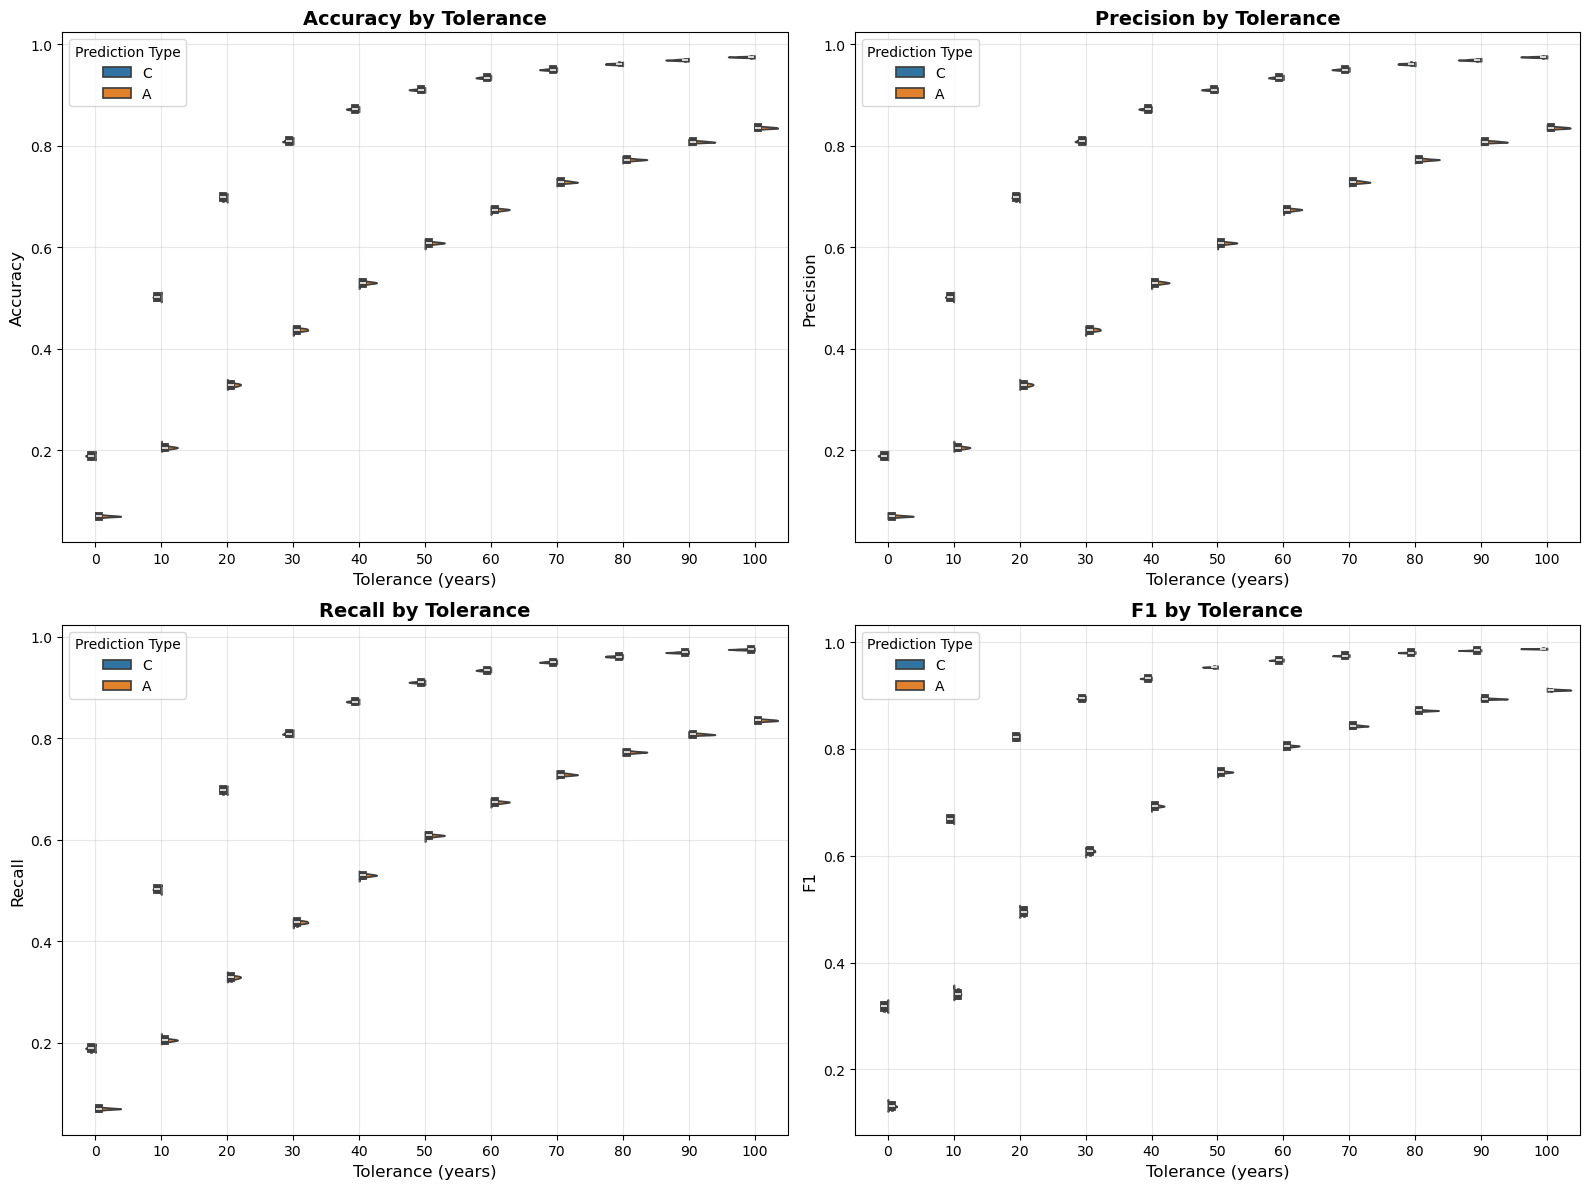

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 데이터 준비: wide format을 long format으로 변환
plot_data_list = []

for tolerance in range(0, 11):
    tol_value = tolerance * 10
    
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        c_col = f'C_{tol_value}_{metric}'
        a_col = f'A_{tol_value}_{metric}'
        
        if c_col in seed_metrics.columns:
            for idx, row in seed_metrics.iterrows():
                plot_data_list.append({
                    'Tolerance': tol_value,
                    'Metric': metric,
                    'Pred_Type': 'C',
                    'Value': row[c_col]
                })
        
        if a_col in seed_metrics.columns:
            for idx, row in seed_metrics.iterrows():
                plot_data_list.append({
                    'Tolerance': tol_value,
                    'Metric': metric,
                    'Pred_Type': 'A',
                    'Value': row[a_col]
                })

plot_data = pd.DataFrame(plot_data_list)

# 그래프 그리기
metrics = ['accuracy', 'precision', 'recall', 'f1']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    metric_data = plot_data[plot_data['Metric'] == metric]
    
    # Boxplot
    sns.boxplot(data=metric_data, x='Tolerance', y='Value', hue='Pred_Type', ax=axes[idx])
    axes[idx].set_title(f'{metric.capitalize()} by Tolerance', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Tolerance (years)', fontsize=12)
    axes[idx].set_ylabel(metric.capitalize(), fontsize=12)
    axes[idx].legend(title='Prediction Type')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Violinplot 버전
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    metric_data = plot_data[plot_data['Metric'] == metric]
    
    # Violinplot
    sns.violinplot(data=metric_data, x='Tolerance', y='Value', hue='Pred_Type', ax=axes[idx], split=True)
    axes[idx].set_title(f'{metric.capitalize()} by Tolerance', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Tolerance (years)', fontsize=12)
    axes[idx].set_ylabel(metric.capitalize(), fontsize=12)
    axes[idx].legend(title='Prediction Type')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_violinplot.png', dpi=300, bbox_inches='tight')
plt.show()

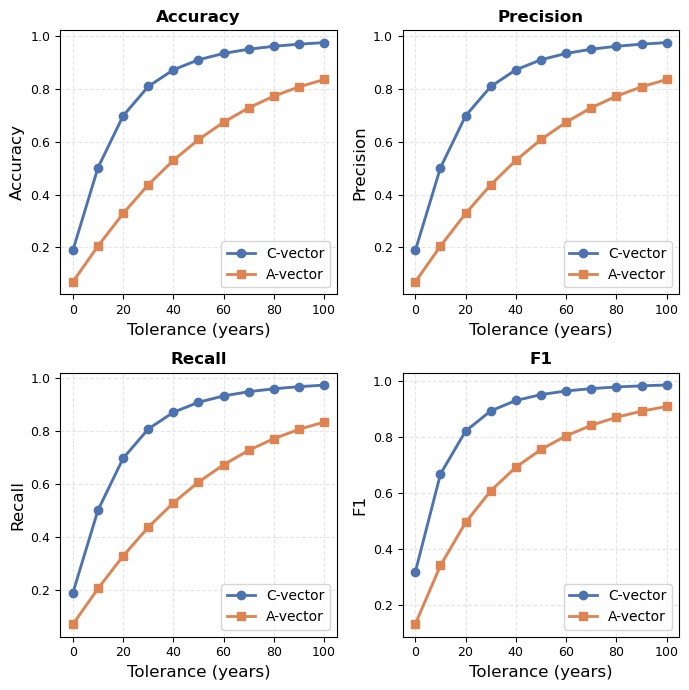

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# seaborn 기본 컬러 팔레트 사용
sns.set_palette("deep")
default_colors = sns.color_palette("deep")

# A4 2column 크기
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    metric_data = plot_data[plot_data['Metric'] == metric]
    
    # C type
    c_data = metric_data[metric_data['Pred_Type'] == 'C'].groupby('Tolerance')['Value'].agg(['mean', 'std'])
    c_data['lower'] = c_data['mean'] - c_data['std']
    c_data['upper'] = c_data['mean'] + c_data['std']
    
    # A type
    a_data = metric_data[metric_data['Pred_Type'] == 'A'].groupby('Tolerance')['Value'].agg(['mean', 'std'])
    a_data['lower'] = a_data['mean'] - a_data['std']
    a_data['upper'] = a_data['mean'] + a_data['std']
    
    # C plot
    axes[idx].plot(c_data.index, c_data['mean'], marker='o', linewidth=2, 
                   markersize=6, color=default_colors[0], label='C-vector', zorder=3)
    axes[idx].fill_between(c_data.index, c_data['lower'], c_data['upper'], 
                           alpha=0.3, color=default_colors[0])
    
    # A plot
    axes[idx].plot(a_data.index, a_data['mean'], marker='s', linewidth=2, 
                   markersize=6, color=default_colors[1], label='A-vector', zorder=3)
    axes[idx].fill_between(a_data.index, a_data['lower'], a_data['upper'], 
                           alpha=0.3, color=default_colors[1])
    
    axes[idx].set_title(f'{metric.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Tolerance (years)', fontsize=12)
    axes[idx].set_ylabel(metric.capitalize(), fontsize=12)
    
    # tick label 크기
    axes[idx].tick_params(axis='both', which='major', labelsize=9)
    
    axes[idx].legend(fontsize=10, loc='lower right')
    axes[idx].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()

# PNG와 PDF로 모두 저장
plt.savefig('metrics_lineplot_publication.png', dpi=300, bbox_inches='tight')
plt.savefig('metrics_lineplot_publication.pdf', bbox_inches='tight')
plt.show()

# Author

In [93]:
df_predicts = pd.read_csv("datas/models/xgboosts_author/predicts_author.csv")
df_trains = pd.read_csv("datas/models/xgboosts_author/trains_author.csv")
df_metrics = pd.read_csv("datas/models/xgboosts_author/metrics_author.csv")

In [94]:
df_metrics[df_metrics['vector']=='A'].describe().to_csv('datas/models/xgboost_author_A.csv')

In [95]:
df_metrics[df_metrics['vector']=='C'].describe().to_csv('datas/models/xgboost_author_C.csv')

### C-vector best

In [54]:
best_seed_C = df_metrics['seed'][df_metrics['accuracy'] == df_metrics['accuracy'].max()].values[0]

In [55]:
df_metrics[df_metrics['seed']==best_seed_C]

,seed,vector,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,log_loss
0,9124,A,0.588826,0.324478,0.326732,0.551004,0.394291,0.324478,1.318697
1,9124,C,0.966102,0.846435,0.883030,0.964923,0.970087,0.846435,0.125869


In [56]:
pd.crosstab(
    df_predicts[f'seed_{best_seed_C}_y_true'],
    df_predicts[f'seed_{best_seed_C}_C_pred'],
    normalize='index', dropna=False).T

seed_9124_y_true,albrecht durer,edouard manet,egon schiele,gustav klimt,jean-francois millet,johannes vermeer,paul cezanne,pierre auguste renoir,rembrandt,vincent van gogh
seed_9124_C_pred,,,,,,,,,,
albrecht durer,0.985437,0.000000,0.000000,0.025,0.00,0.00,0.000000,0.000000,0.000000,0.000000
edouard manet,0.000000,0.762712,0.011905,0.000,0.00,0.00,0.005780,0.008824,0.000000,0.000000
egon schiele,0.000000,0.000000,0.928571,0.050,0.00,0.00,0.000000,0.000000,0.000000,0.000000
gustav klimt,0.000000,0.000000,0.011905,0.875,0.00,0.00,0.000000,0.000000,0.000000,0.000000
jean-francois millet,0.000000,0.000000,0.000000,0.000,0.25,0.00,0.000000,0.000000,0.000000,0.000000
johannes vermeer,0.000000,0.000000,0.000000,0.000,0.00,0.75,0.000000,0.000000,0.000000,0.000000
paul cezanne,0.004854,0.016949,0.000000,0.000,0.00,0.00,0.953757,0.005882,0.000000,0.002188
pierre auguste renoir,0.000000,0.135593,0.000000,0.000,0.00,0.00,0.017341,0.979412,0.000000,0.000000
rembrandt,0.004854,0.033898,0.000000,0.000,0.25,0.25,0.005780,0.000000,0.981651,0.000000


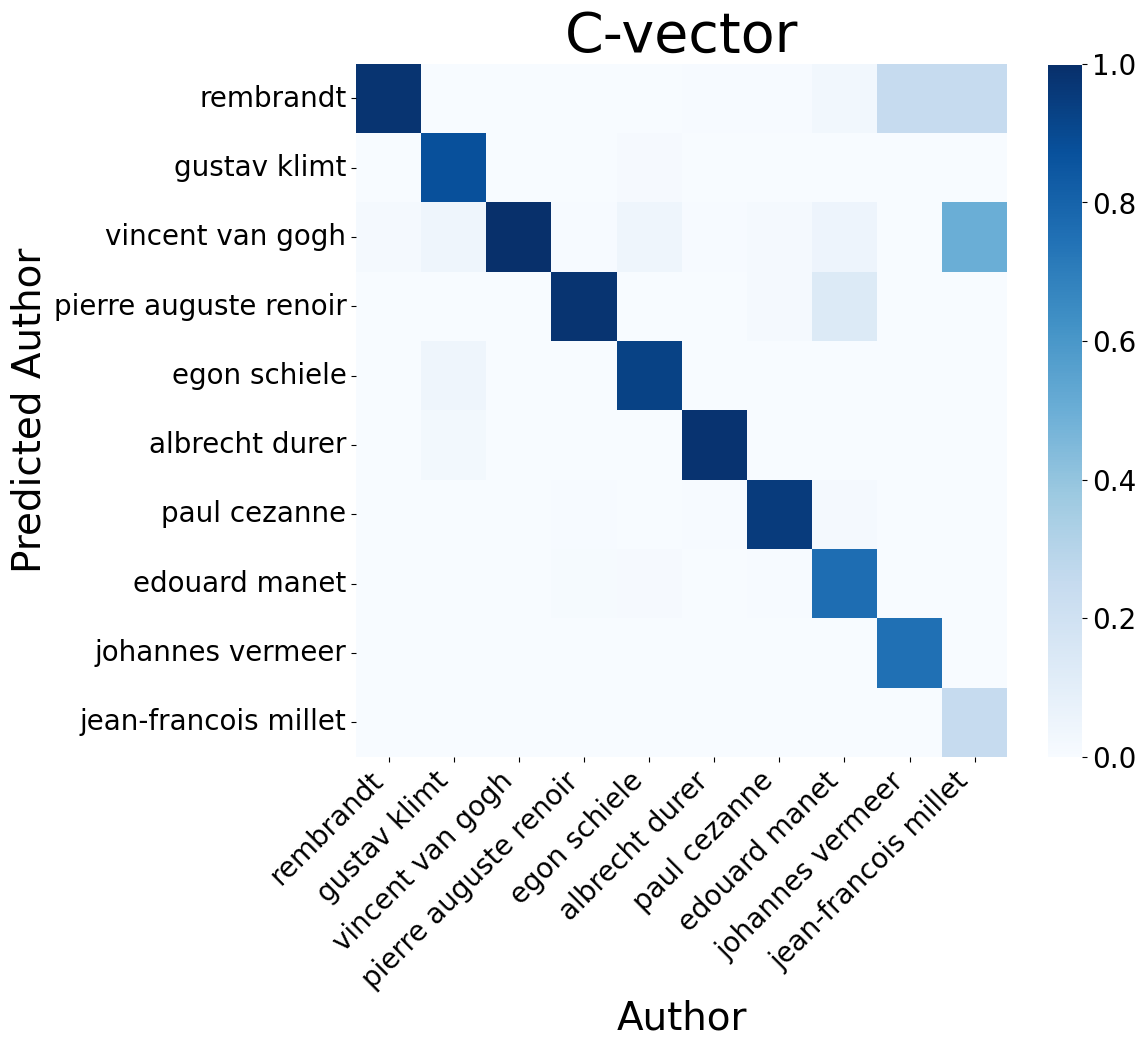

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 클래스 → 연도 매핑
class_labels = ['rembrandt', 'gustav klimt', 'vincent van gogh',
       'pierre auguste renoir', 'egon schiele', 'albrecht durer',
       'paul cezanne', 'edouard manet', 'johannes vermeer',
       'jean-francois millet']

# 혼동행렬
y_test = df_predicts[[f'seed_{best_seed_C}_y_true']]
y_pre_cvec = df_predicts[[f'seed_{best_seed_C}_C_pred']]
cm = confusion_matrix(y_test, y_pre_cvec, labels=class_labels)

# 정규화 (행 단위 비율)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10.5,9))
ax = sns.heatmap(cm_norm.T, annot=False, cmap="Blues", cbar=True,
                 xticklabels=class_labels, yticklabels=class_labels)

# colorbar 객체를 직접 가져와 수정
cbar = ax.collections[0].colorbar
cbar.set_ticks([0.0, 0.2,0.4,0.6,0.8,1])
cbar.ax.tick_params(labelsize=20) 

plt.xlabel("Author", fontsize=28)
plt.ylabel("Predicted Author", fontsize=28)
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.title("C-vector", fontsize=40)

plt.savefig('graph/supple/si12_author_cbest_cvec.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

In [58]:
pd.crosstab(
    df_predicts[f'seed_{best_seed_C}_y_true'],
    df_predicts[f'seed_{best_seed_C}_A_pred'],
    normalize='index', dropna=False).T

seed_9124_y_true,albrecht durer,edouard manet,egon schiele,gustav klimt,jean-francois millet,johannes vermeer,paul cezanne,pierre auguste renoir,rembrandt,vincent van gogh
seed_9124_A_pred,,,,,,,,,,
albrecht durer,0.660194,0.033898,0.035714,0.075,0.00,0.000000,0.005780,0.020588,0.064220,0.059081
edouard manet,0.004854,0.016949,0.000000,0.025,0.00,0.000000,0.000000,0.002941,0.004587,0.000000
egon schiele,0.000000,0.016949,0.178571,0.000,0.00,0.000000,0.000000,0.002941,0.000000,0.008753
paul cezanne,0.019417,0.101695,0.000000,0.025,0.00,0.083333,0.231214,0.014706,0.041284,0.026258
pierre auguste renoir,0.116505,0.423729,0.309524,0.400,0.25,0.416667,0.225434,0.750000,0.096330,0.102845
rembrandt,0.024272,0.118644,0.023810,0.050,0.25,0.416667,0.080925,0.020588,0.637615,0.032823
vincent van gogh,0.174757,0.288136,0.452381,0.425,0.50,0.083333,0.456647,0.188235,0.155963,0.770241


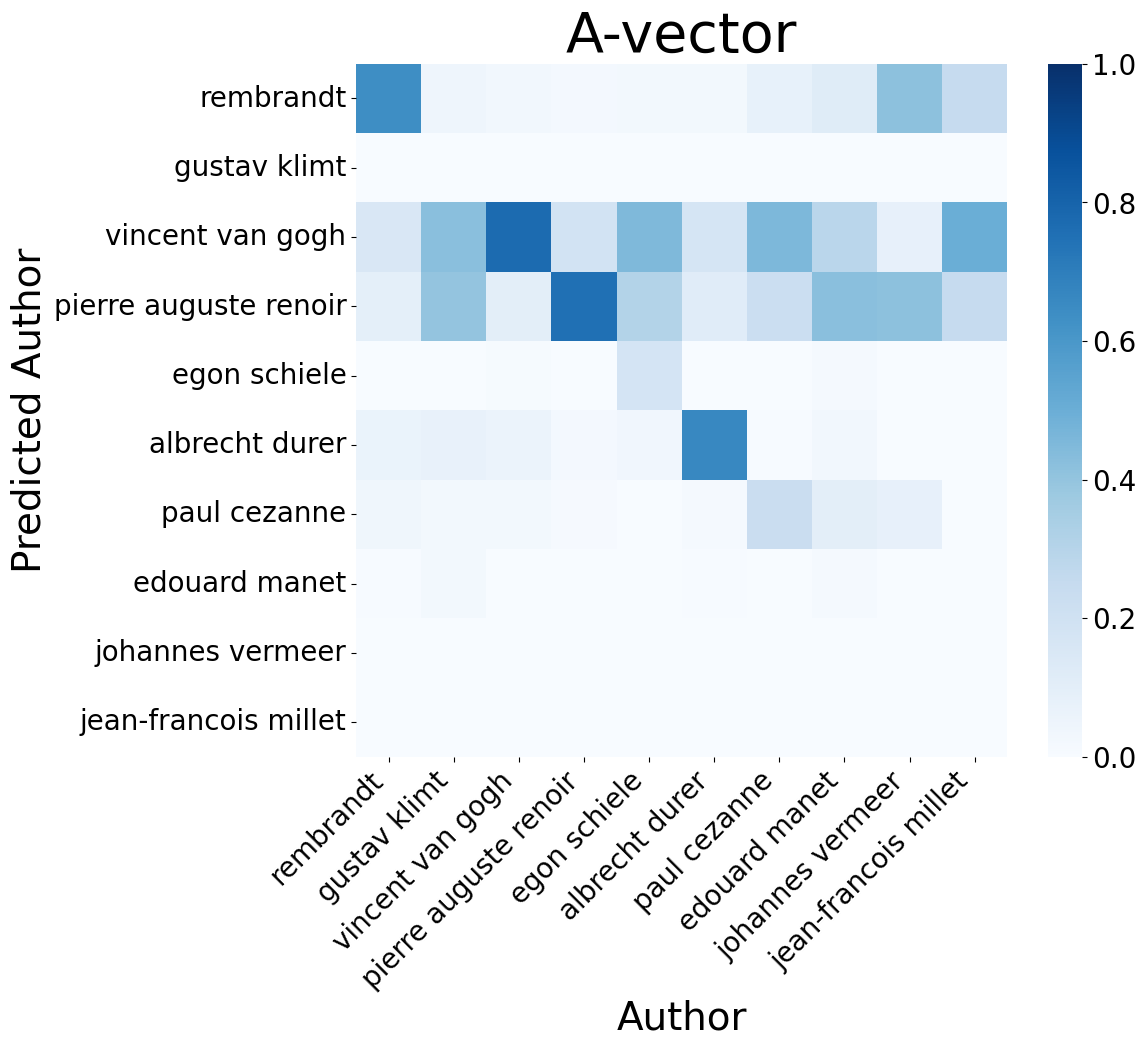

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 클래스 → 연도 매핑
class_labels = ['rembrandt', 'gustav klimt', 'vincent van gogh',
       'pierre auguste renoir', 'egon schiele', 'albrecht durer',
       'paul cezanne', 'edouard manet', 'johannes vermeer',
       'jean-francois millet']

# 혼동행렬
y_test = df_predicts[[f'seed_{best_seed_C}_y_true']]
y_pre_avec = df_predicts[[f'seed_{best_seed_C}_A_pred']]
cm = confusion_matrix(y_test, y_pre_avec, labels=class_labels)

# 정규화 (행 단위 비율)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10.5,9))
ax = sns.heatmap(cm_norm.T, annot=False, cmap="Blues", cbar=True,
                 xticklabels=class_labels, yticklabels=class_labels, vmin=0.0, vmax=1.0 )

# colorbar 객체를 직접 가져와 수정
cbar = ax.collections[0].colorbar
cbar.set_ticks([0.0, 0.2,0.4,0.6,0.8,1])
cbar.ax.tick_params(labelsize=20) 

plt.xlabel("Author", fontsize=28)
plt.ylabel("Predicted Author", fontsize=28)
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.title("A-vector", fontsize=40)

plt.savefig('graph/supple/si12_author_cbest_avec.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

### A-vector best

In [60]:
temp = df_metrics[df_metrics['vector'] == 'A']
best_seed_A = temp['seed'][temp['accuracy'] == temp['accuracy'].max()].values[0]

In [61]:
df_metrics[df_metrics['seed']==best_seed_A]

,seed,vector,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,log_loss
46,2241,A,0.604520,0.336755,0.338299,0.565834,0.411755,0.336755,1.302509
47,2241,C,0.954802,0.827628,0.868347,0.953543,0.963256,0.827628,0.158602


In [62]:
pd.crosstab(
    df_predicts[f'seed_{best_seed_A}_y_true'],
    df_predicts[f'seed_{best_seed_A}_C_pred'],
    normalize='index', dropna=False).T

seed_2241_y_true,albrecht durer,edouard manet,egon schiele,gustav klimt,jean-francois millet,johannes vermeer,paul cezanne,pierre auguste renoir,rembrandt,vincent van gogh
seed_2241_C_pred,,,,,,,,,,
albrecht durer,0.985437,0.000000,0.000000,0.075,0.00,0.000000,0.005780,0.000000,0.004587,0.002188
edouard manet,0.000000,0.762712,0.011905,0.000,0.00,0.000000,0.005780,0.005882,0.000000,0.002188
egon schiele,0.000000,0.000000,0.892857,0.000,0.00,0.000000,0.000000,0.000000,0.000000,0.002188
gustav klimt,0.000000,0.016949,0.000000,0.850,0.00,0.000000,0.000000,0.000000,0.000000,0.000000
jean-francois millet,0.000000,0.000000,0.000000,0.000,0.25,0.000000,0.000000,0.000000,0.000000,0.000000
johannes vermeer,0.000000,0.000000,0.000000,0.000,0.00,0.666667,0.000000,0.000000,0.000000,0.000000
paul cezanne,0.000000,0.033898,0.059524,0.000,0.00,0.000000,0.936416,0.011765,0.000000,0.006565
pierre auguste renoir,0.000000,0.135593,0.011905,0.000,0.00,0.000000,0.005780,0.979412,0.000000,0.006565
rembrandt,0.000000,0.016949,0.000000,0.000,0.25,0.250000,0.000000,0.000000,0.972477,0.000000


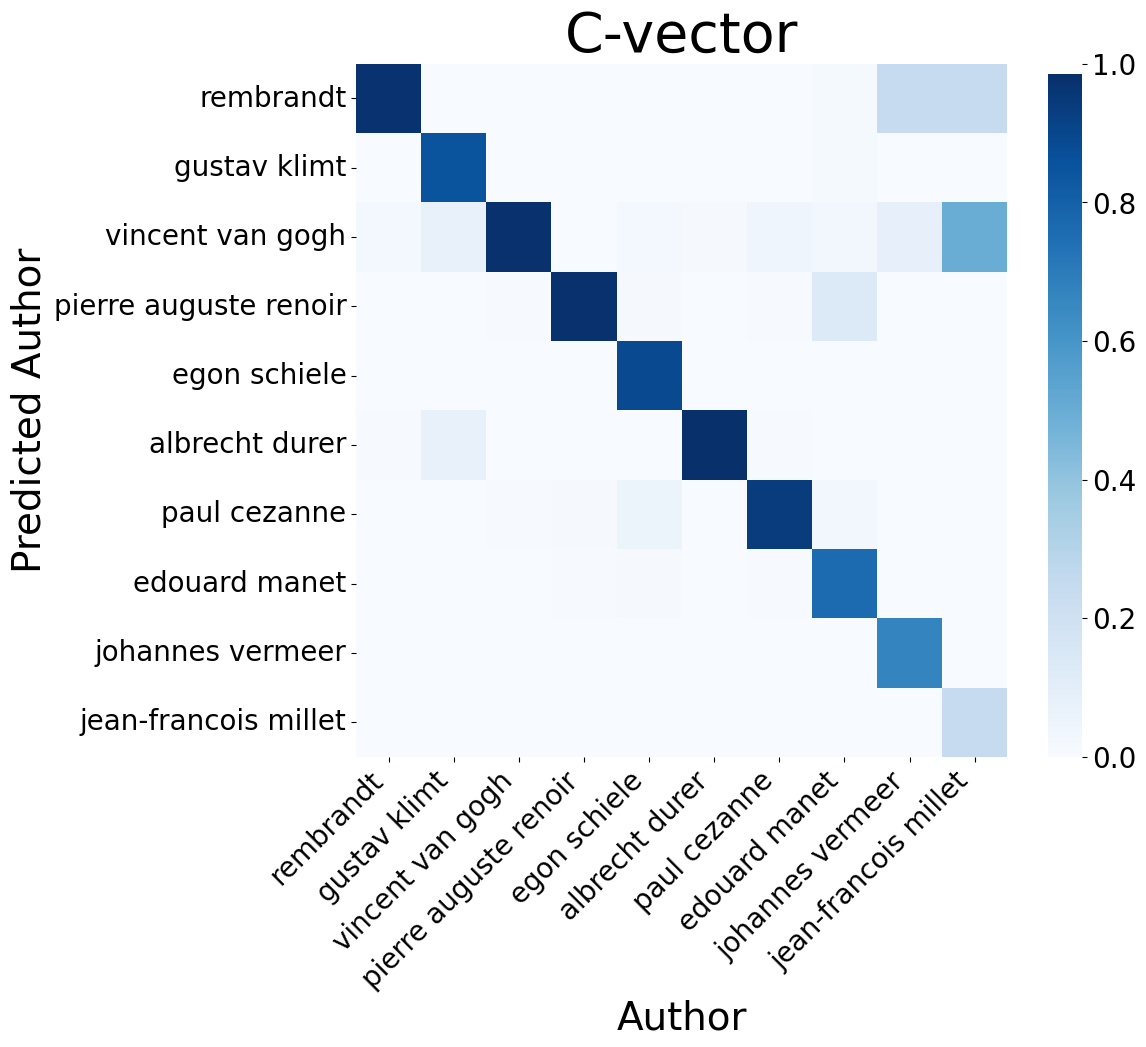

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 클래스 → 연도 매핑
class_labels = ['rembrandt', 'gustav klimt', 'vincent van gogh',
       'pierre auguste renoir', 'egon schiele', 'albrecht durer',
       'paul cezanne', 'edouard manet', 'johannes vermeer',
       'jean-francois millet']

# 혼동행렬
y_test = df_predicts[[f'seed_{best_seed_A}_y_true']]
y_pre_cvec = df_predicts[[f'seed_{best_seed_A}_C_pred']]
cm = confusion_matrix(y_test, y_pre_cvec, labels=class_labels)

# 정규화 (행 단위 비율)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10.5,9))
ax = sns.heatmap(cm_norm.T, annot=False, cmap="Blues", cbar=True,
                 xticklabels=class_labels, yticklabels=class_labels)

# colorbar 객체를 직접 가져와 수정
cbar = ax.collections[0].colorbar
cbar.set_ticks([0.0, 0.2,0.4,0.6,0.8,1])
cbar.ax.tick_params(labelsize=20) 

plt.xlabel("Author", fontsize=28)
plt.ylabel("Predicted Author", fontsize=28)
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.title("C-vector", fontsize=40)

plt.savefig('graph/supple/si12_author_abest_cvec.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

In [64]:
pd.crosstab(
    df_predicts[f'seed_{best_seed_A}_y_true'],
    df_predicts[f'seed_{best_seed_A}_A_pred'],
    normalize='index', dropna=False).T

seed_2241_y_true,albrecht durer,edouard manet,egon schiele,gustav klimt,jean-francois millet,johannes vermeer,paul cezanne,pierre auguste renoir,rembrandt,vincent van gogh
seed_2241_A_pred,,,,,,,,,,
albrecht durer,0.699029,0.016949,0.047619,0.225,0.00,0.083333,0.040462,0.014706,0.059633,0.043764
edouard manet,0.004854,0.016949,0.000000,0.050,0.00,0.000000,0.000000,0.000000,0.004587,0.002188
egon schiele,0.000000,0.000000,0.202381,0.000,0.00,0.000000,0.000000,0.002941,0.004587,0.000000
paul cezanne,0.014563,0.101695,0.035714,0.050,0.00,0.083333,0.219653,0.029412,0.018349,0.021882
pierre auguste renoir,0.082524,0.271186,0.321429,0.250,0.00,0.166667,0.167630,0.744118,0.068807,0.113786
rembrandt,0.014563,0.169492,0.035714,0.075,0.25,0.500000,0.080925,0.017647,0.706422,0.039387
vincent van gogh,0.184466,0.423729,0.357143,0.350,0.75,0.166667,0.491329,0.191176,0.137615,0.778993


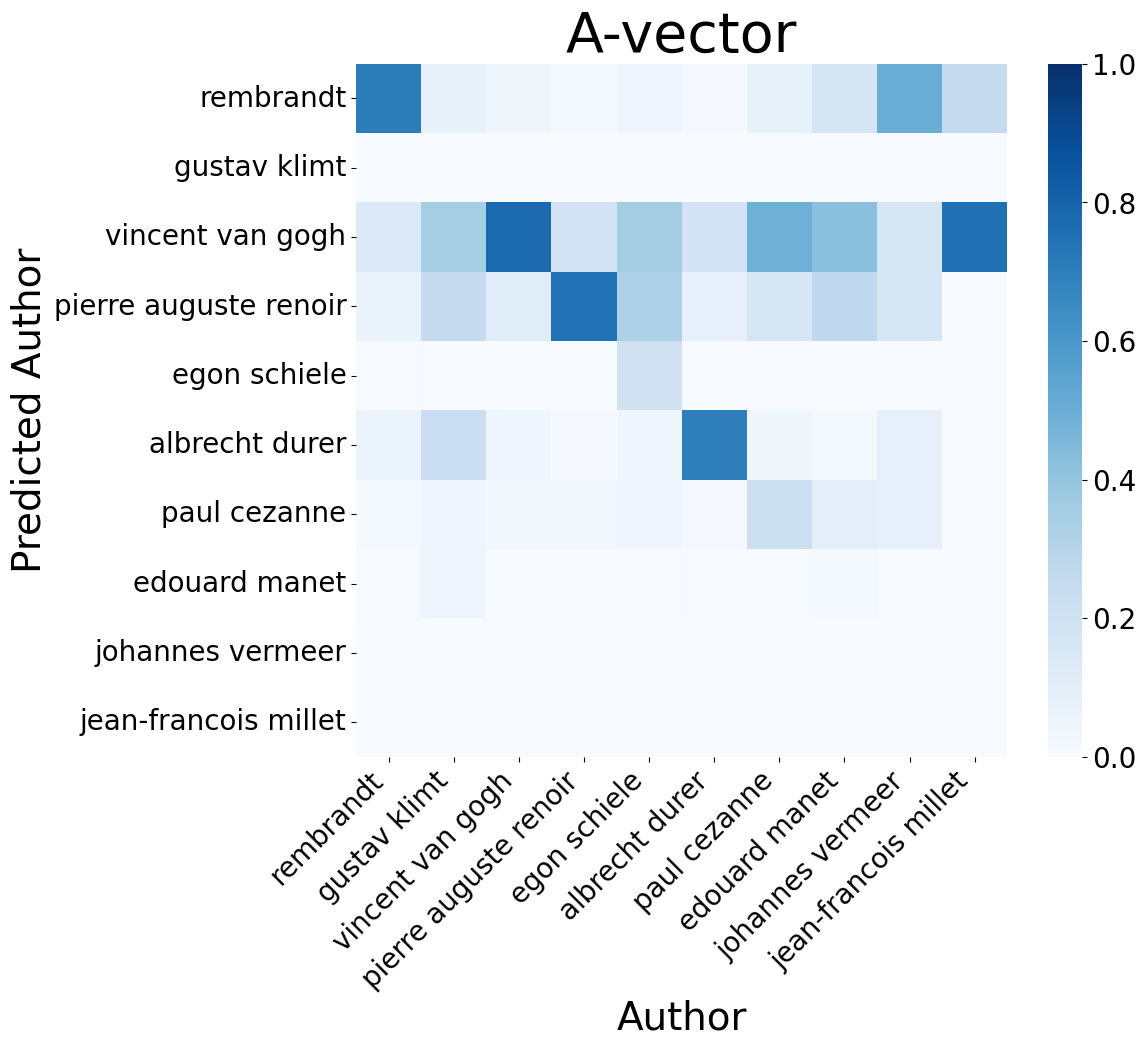

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 클래스 → 연도 매핑
class_labels = ['rembrandt', 'gustav klimt', 'vincent van gogh',
       'pierre auguste renoir', 'egon schiele', 'albrecht durer',
       'paul cezanne', 'edouard manet', 'johannes vermeer',
       'jean-francois millet']

# 혼동행렬
y_test = df_predicts[[f'seed_{best_seed_A}_y_true']]
y_pre_avec = df_predicts[[f'seed_{best_seed_A}_A_pred']]
cm = confusion_matrix(y_test, y_pre_avec, labels=class_labels)

# 정규화 (행 단위 비율)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10.5,9))
ax = sns.heatmap(cm_norm.T, annot=False, cmap="Blues", cbar=True,
                 xticklabels=class_labels, yticklabels=class_labels, vmin=0.0, vmax=1.0, )

# colorbar 객체를 직접 가져와 수정
cbar = ax.collections[0].colorbar
cbar.set_ticks([0.0, 0.2,0.4,0.6,0.8,1])
cbar.ax.tick_params(labelsize=20) 

plt.xlabel("Author", fontsize=28)
plt.ylabel("Predicted Author", fontsize=28)
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.title("A-vector", fontsize=40)

plt.savefig('graph/supple/si12_author_abest_avec.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

# Style

In [97]:
df_predicts = pd.read_csv("datas/models/xgboosts_style/predicts_style.csv")
df_trains = pd.read_csv("datas/models/xgboosts_style/trains_style.csv")
df_metrics = pd.read_csv("datas/models/xgboosts_style/metrics_style.csv")

In [98]:
df_metrics[df_metrics['vector']=='A'].describe().to_csv('datas/models/xgboost_style_A.csv')

In [99]:
df_metrics[df_metrics['vector']=='C'].describe().to_csv('datas/models/xgboost_style_C.csv')

In [67]:
class_labels = ['Realism', 'Expressionism', 'Impressionism', 'Rococo',
       'Northern Renaissance', 'Baroque', 'Romanticism',
       'Art Nouveau (Modern)', 'Post-Impressionism', 'Symbolism']

### C-vector best

In [68]:
best_seed_C = df_metrics['seed'][df_metrics['accuracy'] == df_metrics['accuracy'].max()].values[0]

In [69]:
df_metrics[df_metrics['seed']==best_seed_C]

,seed,vector,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,log_loss
104,2327,A,0.359537,0.251190,0.248779,0.306853,0.417125,0.251190,1.830961
105,2327,C,0.771019,0.761281,0.774110,0.769939,0.791342,0.761281,0.661780


In [70]:
pd.crosstab(
    df_predicts[f'seed_{best_seed_C}_y_true'],
    df_predicts[f'seed_{best_seed_C}_C_pred'],
    normalize='index', dropna=False).T

seed_2327_y_true,Art Nouveau (Modern),Baroque,Expressionism,Impressionism,Northern Renaissance,Post-Impressionism,Realism,Rococo,Romanticism,Symbolism
seed_2327_C_pred,,,,,,,,,,
Art Nouveau (Modern),0.715527,0.001579,0.030516,0.004145,0.008197,0.017857,0.015847,0.000000,0.009551,0.060314
Baroque,0.000000,0.902920,0.000000,0.000345,0.034426,0.000000,0.005421,0.102713,0.027528,0.001206
Expressionism,0.045603,0.000000,0.794210,0.010363,0.003279,0.078734,0.013761,0.000000,0.006742,0.054282
Impressionism,0.042345,0.000789,0.040689,0.846978,0.000000,0.203734,0.087156,0.000000,0.026404,0.047045
Northern Renaissance,0.001086,0.009471,0.000782,0.000345,0.921311,0.000812,0.000834,0.001938,0.002809,0.003619
Post-Impressionism,0.040174,0.000789,0.061815,0.034888,0.000000,0.589286,0.015847,0.000000,0.005056,0.022919
Realism,0.091205,0.024467,0.046166,0.085665,0.011475,0.091721,0.767723,0.023256,0.156742,0.129071
Rococo,0.002172,0.029992,0.000000,0.000000,0.000000,0.000000,0.001251,0.724806,0.029775,0.001206
Romanticism,0.011944,0.029203,0.001565,0.009326,0.019672,0.004870,0.081735,0.147287,0.726404,0.056695


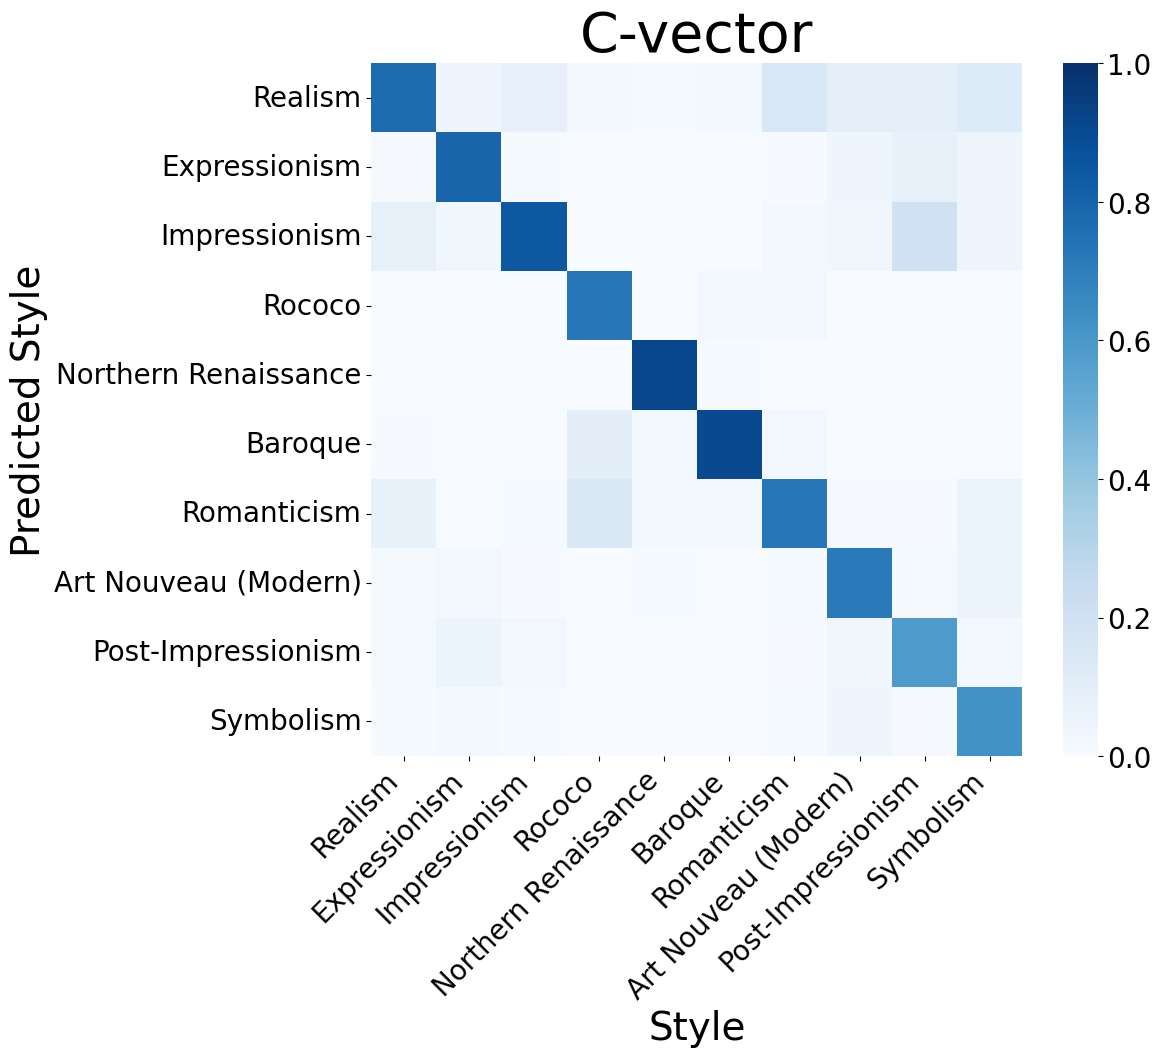

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 혼동행렬
y_test = df_predicts[[f'seed_{best_seed_C}_y_true']]
y_pre_cvec = df_predicts[[f'seed_{best_seed_C}_C_pred']]
cm = confusion_matrix(y_test, y_pre_cvec, labels=class_labels)

# 정규화 (행 단위 비율)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10.5,9))
ax = sns.heatmap(cm_norm.T, annot=False, cmap="Blues", cbar=True,
                 xticklabels=class_labels, yticklabels=class_labels, vmin=0.0, vmax=1.0)

# colorbar 객체를 직접 가져와 수정
cbar = ax.collections[0].colorbar
cbar.set_ticks([0.0, 0.2,0.4,0.6,0.8,1])
cbar.ax.tick_params(labelsize=20) 

plt.xlabel("Style", fontsize=28)
plt.ylabel("Predicted Style", fontsize=28)
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.title("C-vector", fontsize=40)

plt.savefig('graph/supple/si12_style_cbest_cvec.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

In [72]:
pd.crosstab(
    df_predicts[f'seed_{best_seed_C}_y_true'],
    df_predicts[f'seed_{best_seed_C}_A_pred'],
    normalize='index', dropna=False).T

seed_2327_y_true,Art Nouveau (Modern),Baroque,Expressionism,Impressionism,Northern Renaissance,Post-Impressionism,Realism,Rococo,Romanticism,Symbolism
seed_2327_A_pred,,,,,,,,,,
Art Nouveau (Modern),0.221498,0.003946,0.057121,0.003454,0.019672,0.012987,0.021685,0.001938,0.011236,0.026538
Baroque,0.017372,0.405683,0.033646,0.011744,0.073770,0.017857,0.059216,0.265504,0.097191,0.027744
Expressionism,0.094463,0.011050,0.137715,0.010017,0.032787,0.035714,0.011259,0.001938,0.021348,0.044632
Impressionism,0.353963,0.137332,0.431142,0.778929,0.431148,0.702110,0.315680,0.158915,0.280337,0.494572
Northern Renaissance,0.004343,0.001579,0.000782,0.000691,0.036066,0.001623,0.000834,0.000000,0.002247,0.001206
Post-Impressionism,0.011944,0.001579,0.016432,0.003109,0.004918,0.011364,0.002919,0.000000,0.003371,0.004825
Realism,0.236699,0.296764,0.261346,0.158895,0.304918,0.185877,0.488324,0.213178,0.309551,0.248492
Rococo,0.001086,0.003946,0.000782,0.000345,0.003279,0.001623,0.001251,0.087209,0.011798,0.001206
Romanticism,0.048860,0.138122,0.052426,0.027288,0.090164,0.027597,0.096330,0.267442,0.260674,0.066345


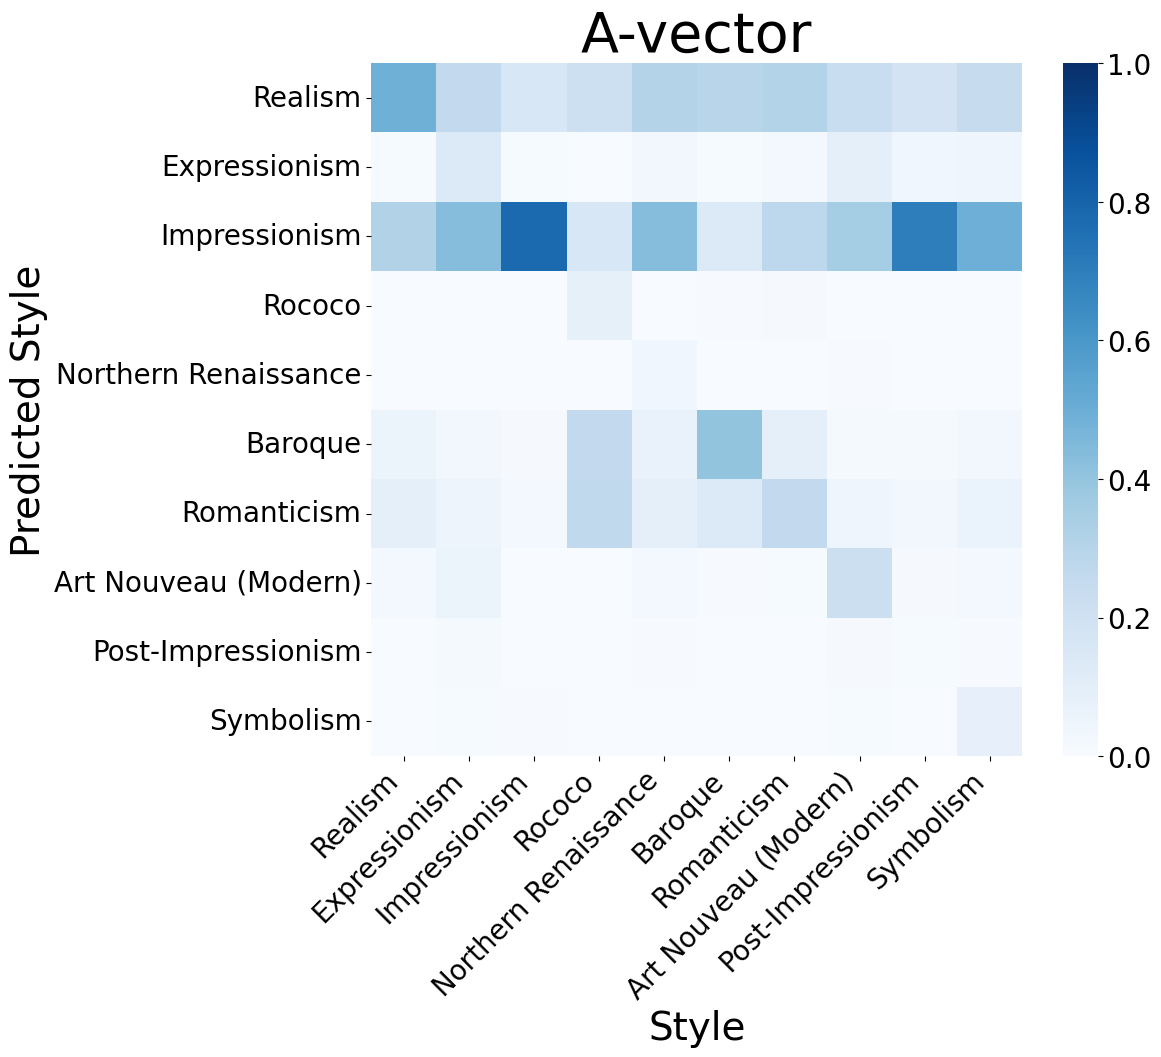

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 혼동행렬
y_test = df_predicts[[f'seed_{best_seed_C}_y_true']]
y_pre_avec = df_predicts[[f'seed_{best_seed_C}_A_pred']]
cm = confusion_matrix(y_test, y_pre_avec, labels=class_labels)

# 정규화 (행 단위 비율)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10.5,9))
ax = sns.heatmap(cm_norm.T, annot=False, cmap="Blues", cbar=True,
                 xticklabels=class_labels, yticklabels=class_labels, vmin=0.0, vmax=1.0, )

# colorbar 객체를 직접 가져와 수정
cbar = ax.collections[0].colorbar
cbar.set_ticks([0.0, 0.2,0.4,0.6,0.8,1])
cbar.ax.tick_params(labelsize=20) 

plt.xlabel("Style", fontsize=28)
plt.ylabel("Predicted Style", fontsize=28)
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.title("A-vector", fontsize=40)

plt.savefig('graph/supple/si12_style_cbest_avec.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

### A-vector best

In [75]:
temp = df_metrics[df_metrics['vector'] == 'A']
best_seed_A = temp['seed'][temp['accuracy'] == temp['accuracy'].max()].values[0]

In [76]:
df_metrics[df_metrics['seed']==best_seed_A]

,seed,vector,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,log_loss
54,1208,A,0.367259,0.259244,0.257674,0.315776,0.420264,0.259244,1.827056
55,1208,C,0.765846,0.754372,0.768104,0.763866,0.787737,0.754372,0.664097


In [77]:
pd.crosstab(
    df_predicts[f'seed_{best_seed_A}_y_true'],
    df_predicts[f'seed_{best_seed_A}_C_pred'],
    normalize='index', dropna=False).T

seed_1208_y_true,Art Nouveau (Modern),Baroque,Expressionism,Impressionism,Northern Renaissance,Post-Impressionism,Realism,Rococo,Romanticism,Symbolism
seed_1208_C_pred,,,,,,,,,,
Art Nouveau (Modern),0.728556,0.001579,0.018779,0.003454,0.006557,0.014610,0.017932,0.000000,0.010112,0.069964
Baroque,0.001086,0.919495,0.001565,0.000345,0.047541,0.000812,0.006255,0.093023,0.021348,0.002413
Expressionism,0.051031,0.000000,0.778560,0.008636,0.001639,0.110390,0.016681,0.000000,0.003371,0.053076
Impressionism,0.033659,0.000789,0.053991,0.845941,0.000000,0.216721,0.103837,0.001938,0.028090,0.061520
Northern Renaissance,0.002172,0.009471,0.000782,0.000000,0.906557,0.001623,0.001668,0.000000,0.002809,0.002413
Post-Impressionism,0.034745,0.000000,0.059468,0.031088,0.000000,0.538149,0.011259,0.000000,0.006742,0.027744
Realism,0.066232,0.017364,0.061815,0.094646,0.016393,0.098214,0.763553,0.019380,0.147753,0.107358
Rococo,0.001086,0.022099,0.000000,0.000000,0.000000,0.000000,0.000834,0.718992,0.030899,0.000000
Romanticism,0.014115,0.026835,0.003912,0.007945,0.016393,0.004058,0.070058,0.166667,0.735955,0.067551


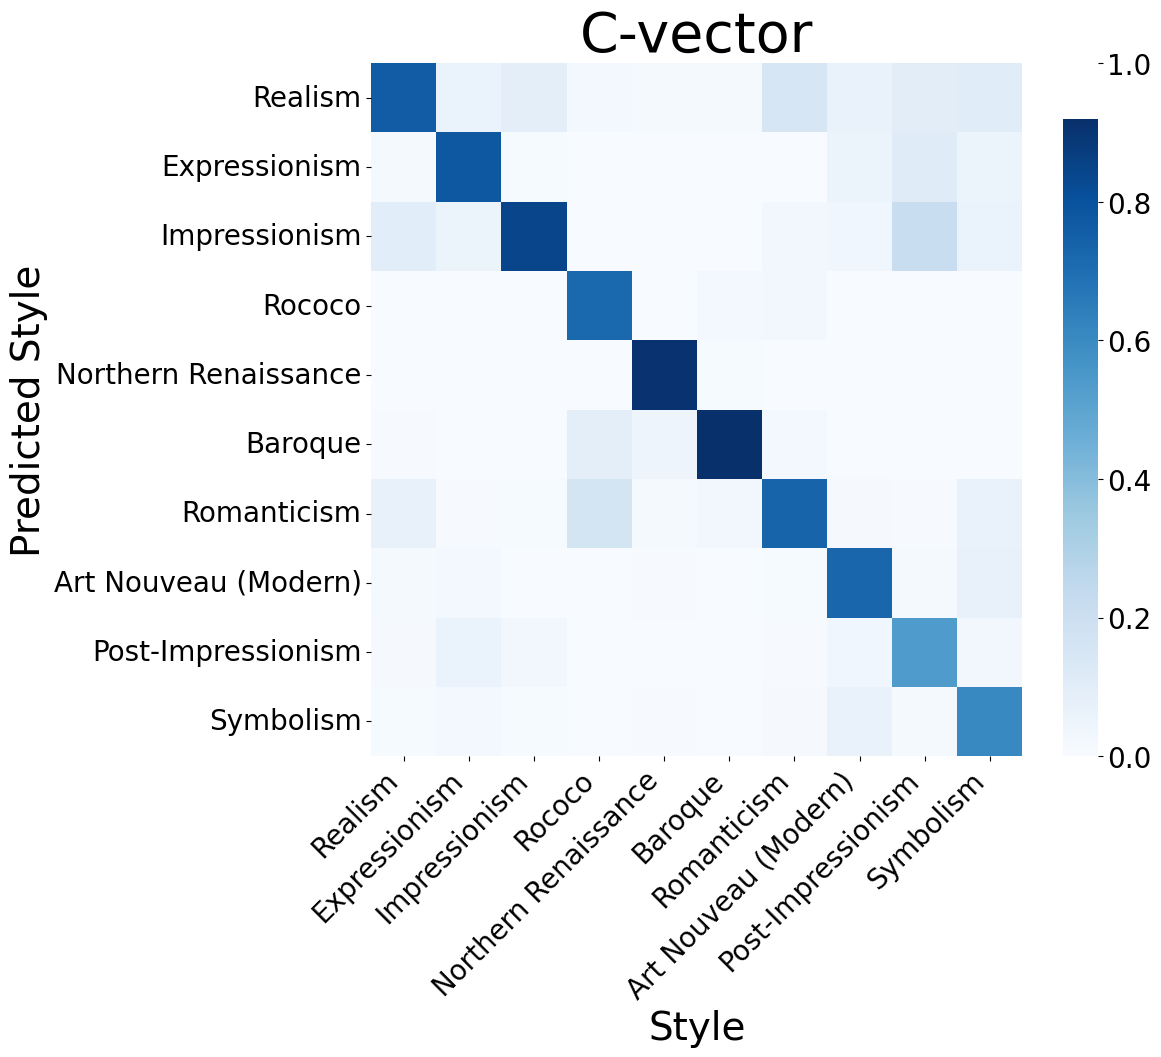

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 혼동행렬
y_test = df_predicts[[f'seed_{best_seed_A}_y_true']]
y_pre_cvec = df_predicts[[f'seed_{best_seed_A}_C_pred']]
cm = confusion_matrix(y_test, y_pre_cvec, labels=class_labels)

# 정규화 (행 단위 비율)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10.5,9))
ax = sns.heatmap(cm_norm.T, annot=False, cmap="Blues", cbar=True,
                 xticklabels=class_labels, yticklabels=class_labels)

# colorbar 객체를 직접 가져와 수정
cbar = ax.collections[0].colorbar
cbar.set_ticks([0.0, 0.2,0.4,0.6,0.8,1])
cbar.ax.tick_params(labelsize=20) 

plt.xlabel("Style", fontsize=28)
plt.ylabel("Predicted Style", fontsize=28)
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.title("C-vector", fontsize=40)

plt.savefig('graph/supple/si12_style_abest_cvec.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

In [79]:
pd.crosstab(
    df_predicts[f'seed_{best_seed_A}_y_true'],
    df_predicts[f'seed_{best_seed_A}_A_pred'],
    normalize='index', dropna=False).T

seed_1208_y_true,Art Nouveau (Modern),Baroque,Expressionism,Impressionism,Northern Renaissance,Post-Impressionism,Realism,Rococo,Romanticism,Symbolism
seed_1208_A_pred,,,,,,,,,,
Art Nouveau (Modern),0.251900,0.008682,0.054773,0.003454,0.024590,0.011364,0.017098,0.001938,0.017416,0.022919
Baroque,0.014115,0.418311,0.029734,0.014162,0.080328,0.019481,0.065888,0.244186,0.091573,0.022919
Expressionism,0.110749,0.007893,0.128326,0.016926,0.052459,0.031656,0.011676,0.005814,0.016292,0.051870
Impressionism,0.344191,0.146014,0.415493,0.781693,0.398361,0.684253,0.309008,0.147287,0.261798,0.487334
Northern Renaissance,0.005429,0.003157,0.000782,0.000691,0.040984,0.000000,0.000417,0.001938,0.002247,0.003619
Post-Impressionism,0.009772,0.001579,0.016432,0.002763,0.004918,0.017857,0.003753,0.000000,0.000000,0.013269
Realism,0.199783,0.271507,0.295775,0.148532,0.311475,0.195617,0.491243,0.224806,0.308427,0.241255
Rococo,0.001086,0.006314,0.003130,0.000691,0.003279,0.001623,0.002085,0.093023,0.012921,0.002413
Romanticism,0.052117,0.135754,0.045383,0.026943,0.081967,0.033279,0.096330,0.275194,0.287079,0.072376


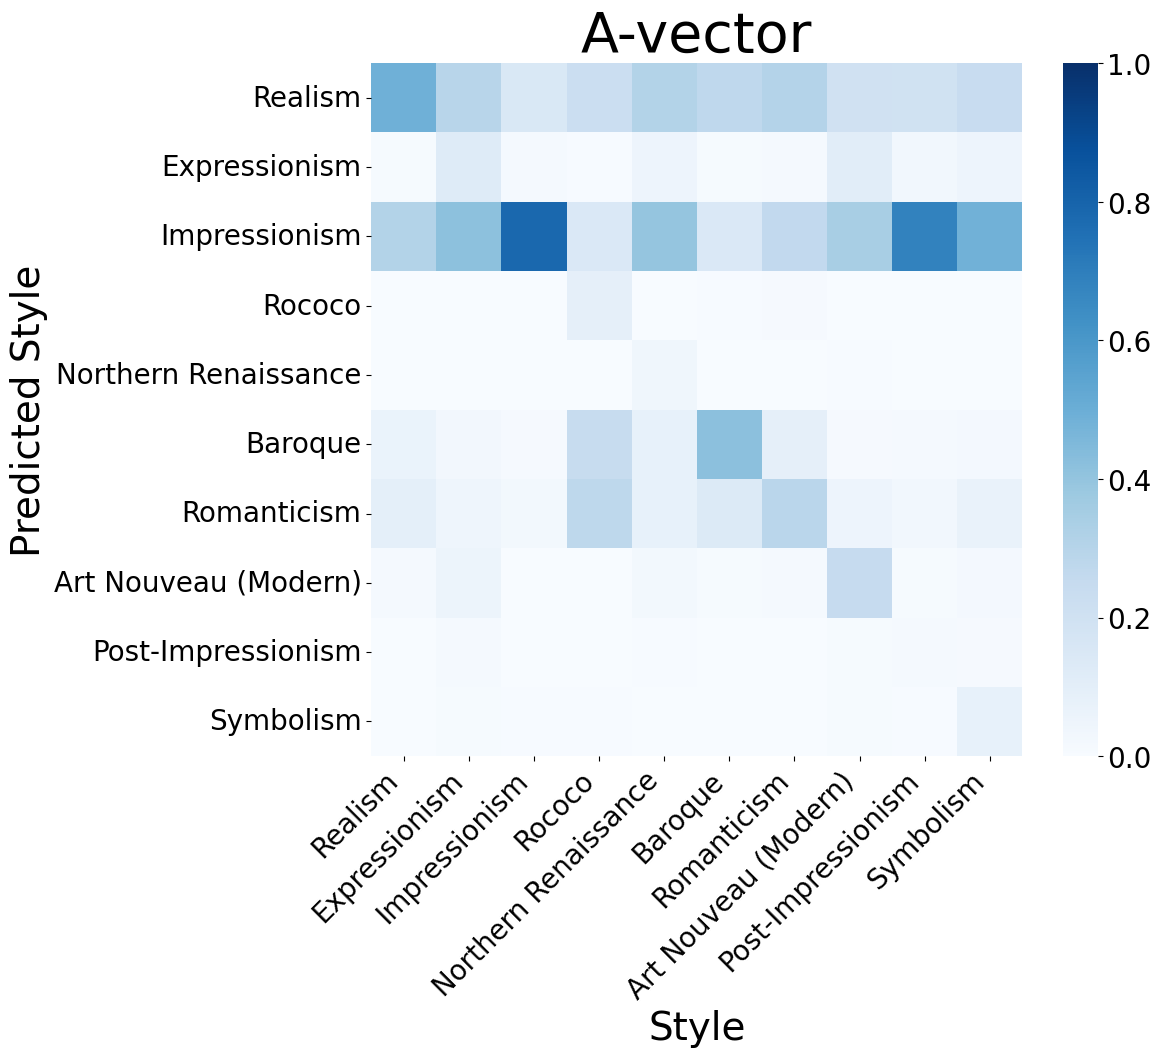

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 혼동행렬
y_test = df_predicts[[f'seed_{best_seed_A}_y_true']]
y_pre_avec = df_predicts[[f'seed_{best_seed_A}_A_pred']]
cm = confusion_matrix(y_test, y_pre_avec, labels=class_labels)

# 정규화 (행 단위 비율)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10.5,9))
ax = sns.heatmap(cm_norm.T, annot=False, cmap="Blues", cbar=True,
                 xticklabels=class_labels, yticklabels=class_labels, vmin=0.0, vmax=1.0, )

# colorbar 객체를 직접 가져와 수정
cbar = ax.collections[0].colorbar
cbar.set_ticks([0.0, 0.2,0.4,0.6,0.8,1])
cbar.ax.tick_params(labelsize=20) 

plt.xlabel("Style", fontsize=28)
plt.ylabel("Predicted Style", fontsize=28)
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.title("A-vector", fontsize=40)

plt.savefig('graph/supple/si12_style_abest_avec.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()